In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
profit_loss = pd.read_csv(
    "exports/clean_profit_loss.csv"
)

balance_sheet = pd.read_csv(
    "exports/clean_balance_sheet.csv"
)

cash_flow = pd.read_csv(
    "exports/clean_cash_flow.csv"
)

analysis = pd.read_csv(
    "exports/clean_analysis.csv"
)

In [3]:
profit_loss["net_margin"] = (
    profit_loss["net_profit"] /
    (profit_loss["sales"] + 1)
) * 100

In [4]:
profit_loss["op_margin"] = (
    profit_loss["operating_profit"] /
    (profit_loss["sales"] + 1)
) * 100

In [5]:
balance_sheet["de_ratio"] = (
    balance_sheet["borrowings"] /
    (
        balance_sheet["equity_capital"] +
        balance_sheet["reserves"] +
        1
    )
)

In [6]:
cash_merged = cash_flow.merge(
    profit_loss[
        [
            "company_id",
            "year",
            "net_profit"
        ]
    ],
    on=["company_id", "year"],
    how="left"
)

cash_merged["cash_conversion"] = (
    cash_merged["operating_activity"] /
    (cash_merged["net_profit"] + 1)
)

In [7]:
sales_growth = (
    profit_loss.groupby("company_id")["sales"]
    .agg(["first", "last"])
)

sales_growth["avg_growth_3y"] = (
    (
        sales_growth["last"] /
        (sales_growth["first"] + 1)
    ) ** (1/3) - 1
) * 100

In [8]:
dividend = (
    profit_loss.groupby("company_id")[
        "dividend_payout"
    ]
    .mean()
)

In [10]:
balance_sheet["roe"] = (
    balance_sheet["reserves"] /
    (
        balance_sheet["equity_capital"] + 1
    )
) * 100

In [11]:
balance_sheet["de_ratio"] = (
    balance_sheet["borrowings"] /
    (
        balance_sheet["equity_capital"] +
        balance_sheet["reserves"] +
        1
    )
)

In [12]:
avg_roe = (
    balance_sheet.groupby("company_id")[
        "roe"
    ]
    .mean()
)

avg_de = (
    balance_sheet.groupby("company_id")[
        "de_ratio"
    ]
    .mean()
)

In [13]:
avg_opm = (
    profit_loss.groupby("company_id")[
        "op_margin"
    ]
    .mean()
)

avg_roe = (
    balance_sheet.groupby("company_id")[
        "roe"
    ]
    .mean()
)

avg_de = (
    balance_sheet.groupby("company_id")[
        "de_ratio"
    ]
    .mean()
)

avg_cash_conversion = (
    cash_merged.groupby("company_id")[
        "cash_conversion"
    ]
    .mean()
)

In [14]:
feature_matrix = pd.DataFrame({
    "avg_opm": avg_opm,
    "avg_roe": avg_roe,
    "avg_growth_3y": sales_growth["avg_growth_3y"],
    "avg_de_ratio": avg_de,
    "avg_cash_conversion": avg_cash_conversion,
    "avg_dividend": dividend
})

In [15]:
feature_matrix.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

feature_matrix.fillna(0, inplace=True)

In [16]:
feature_matrix.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

feature_matrix.fillna(0, inplace=True)

In [17]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    feature_matrix
)

In [18]:
similarity_matrix = cosine_similarity(
    scaled_features
)

In [19]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=feature_matrix.index,
    columns=feature_matrix.index
)

In [20]:
peer_mapping = []

for company in similarity_df.index:

    peers = (
        similarity_df[company]
        .sort_values(ascending=False)
        .iloc[1:6]
    )

    for peer, score in peers.items():

        peer_mapping.append({
            "company_id": company,
            "peer_company": peer,
            "similarity_score": score
        })

In [21]:
peer_mapping_df = pd.DataFrame(
    peer_mapping
)

peer_mapping_df.head(20)

,company_id,peer_company,similarity_score
0,ABB,AMBUJACEM,0.986983
1,ABB,ASIANPAINT,0.985073
2,ABB,HCLTECH,0.981087
3,ABB,BAJAJ-AUTO,0.980212
4,ABB,BRITANNIA,0.978846
5,ADANIENSOL,BAJAJFINSV,0.280898
6,ADANIENSOL,ADANIGREEN,0.275819
7,ADANIENSOL,DMART,0.237451
8,ADANIENSOL,VBL,0.196688
9,ADANIENSOL,BAJFINANCE,0.191720


In [22]:
peer_mapping_df[
    peer_mapping_df["company_id"] == "TCS"
]

,company_id,peer_company,similarity_score
435,TCS,INFY,0.987171
436,TCS,NESTLEIND,0.983810
437,TCS,TORNTPHARM,0.979755
438,TCS,IRCTC,0.968470
439,TCS,ITC,0.967137


In [23]:
top_companies = [
    "TCS",
    "INFY",
    "WIPRO",
    "HDFCBANK",
    "ICICIBANK",
    "RELIANCE"
]

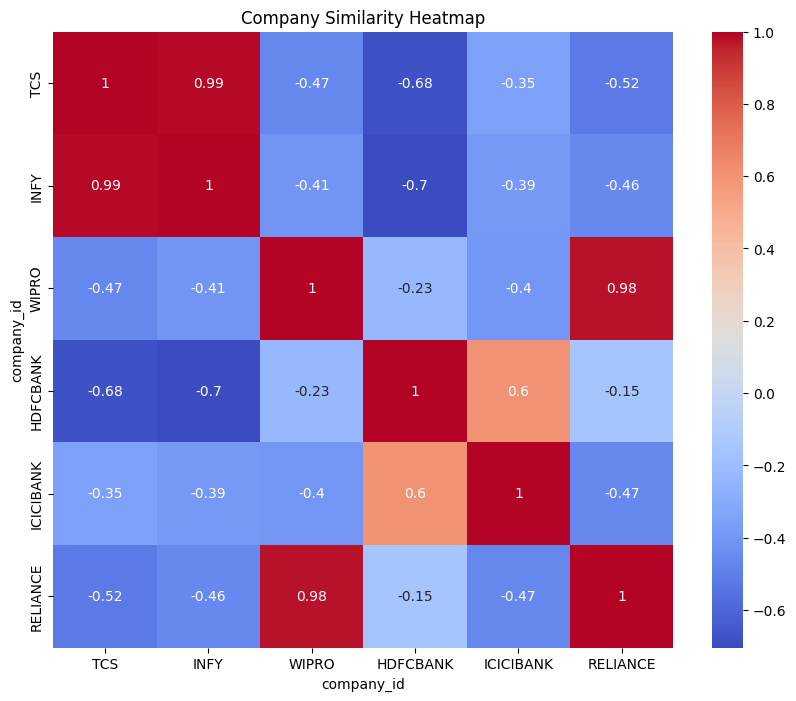

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(
    similarity_df.loc[
        top_companies,
        top_companies
    ],
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Company Similarity Heatmap"
)

plt.show()

In [25]:
peer_mapping_df.to_csv(
    "exports/peer_mapping.csv",
    index=False
)